In [1]:
# Import libraries for data processing, audio analysis, and visualization
import pandas as pd
import numpy as np
import soundfile as sf
import librosa
from pathlib import Path
from collections import Counter
import re
import matplotlib.pyplot as plt

# Jember Javanese Spontaneous Dataset
# These paths point to the metadata and audio files for the Jember dataset
JEMBER_TSV = "Jember Javanese Spontaneous Speech Corpus/Jember Javanese Spontaneous Speech Corpus - 1-200.tsv"
JEMBER_AUDIO_DIR = "Jember Javanese Spontaneous Speech Corpus/mp3 audio"
LANGUAGE = "Javanese"
DATASET_NAME = "Jember Spontaneous"

## 1. Setup and Imports

Import required libraries and configure dataset paths. This cell establishes connection to the Jember Javanese spontaneous speech dataset metadata and audio files.

# Jember Javanese Spontaneous Speech Dataset Analysis

This notebook analyzes the Jember spontaneous Javanese speech dataset. It performs exploratory data analysis including:
- Loading and inspecting dataset structure
- Computing segment durations and statistics
- Text normalization and transcription analysis
- Vocabulary coverage and word frequency analysis
- Speaker and conversation-level statistics
- Data quality checks

In [2]:
# Load the Jember metadata file (TSV format)
# This file contains one row per speech segment with transcriptions, timestamps, speakers, etc.
jember_df = pd.read_csv(JEMBER_TSV, sep="\t")

print(f"{DATASET_NAME} Dataset ({LANGUAGE})")
print(f"Shape: {jember_df.shape}")
print(f"Columns: {jember_df.columns.tolist()}\n")

jember_df.head()

Jember Spontaneous Dataset (Javanese)
Shape: (6679, 4)
Columns: ['Audio file name', 'start', 'end', 'text']



,Audio file name,start,end,text
0,1,0:00:00,0:00:03,Oke. Bismillahirrahmanirrahim.
1,1,0:00:03,0:00:05,"Langsung ae ya, aja suwi-suwi."
2,1,0:00:05,0:00:07,Soale aku sibuk.
3,1,0:00:07,0:00:10,Nèngdi tempat wisata alam populer nèng Indonesia?
4,1,0:00:10,0:00:11,Akèh sih.


## 2. Load Dataset Metadata

Read the Jember metadata TSV file containing segment information (speaker, transcription, timestamps, etc.). Display basic dataset statistics and a preview of the first few rows to understand the data structure.

In [3]:
# Helper function to get duration from audio file metadata
def get_duration(path):
    """Calculate audio duration in seconds from file."""
    try:
        info = sf.info(str(path))
        return info.frames / info.samplerate
    except Exception as e:
        print(f"Error reading {path}: {e}")
        return np.nan

# If dataset has audio filenames, compute their durations
# This gives us actual audio length for each segment
if "audio_filename" in jember_df.columns:
    jember_df["duration_s"] = jember_df["audio_filename"].apply(
        lambda f: get_duration(Path(JEMBER_AUDIO_DIR) / f)
    )
    print("Audio duration statistics:")
    print(jember_df["duration_s"].describe())

## 3. Compute Audio Durations (if audio files available)

If the dataset has audio_filename column, calculate the duration of each audio file using soundfile. This allows us to understand the distribution of segment lengths in the dataset.

In [4]:
# Helper function to parse timestamps in various formats (HH:MM:SS, MM:SS, or just SS)
def parse_ts(ts):
    """Parse timestamp in format HH:MM:SS, MM:SS, or SS."""
    parts = [float(p) for p in str(ts).split(":")]
    if len(parts) == 3: 
        h, m, s = parts
    elif len(parts) == 2: 
        h, m, s = 0, *parts
    else: 
        h, m, s = 0, 0, parts[0]
    return h*3600 + m*60 + s

# Parse segment boundaries if present in the metadata
# This computes duration as (end_timestamp - start_timestamp)
if "start" in jember_df.columns and "end" in jember_df.columns:
    jember_df["start_s"] = jember_df["start"].apply(parse_ts)
    jember_df["end_s"] = jember_df["end"].apply(parse_ts)
    jember_df["duration_s"] = jember_df["end_s"] - jember_df["start_s"]
    
    print("Segment duration statistics:")
    print(jember_df["duration_s"].describe())

Segment duration statistics:
count    6679.000000
mean        5.375954
std         3.352304
min       -30.000000
25%         3.000000
50%         5.000000
75%         7.000000
max        29.000000
Name: duration_s, dtype: float64


## 4. Parse Segment Boundaries (if timestamp-based segmentation)

If the dataset has start/end timestamps (HH:MM:SS format), parse them and compute segment duration. This is used when segments are defined by boundaries within longer audio files rather than as separate audio files.

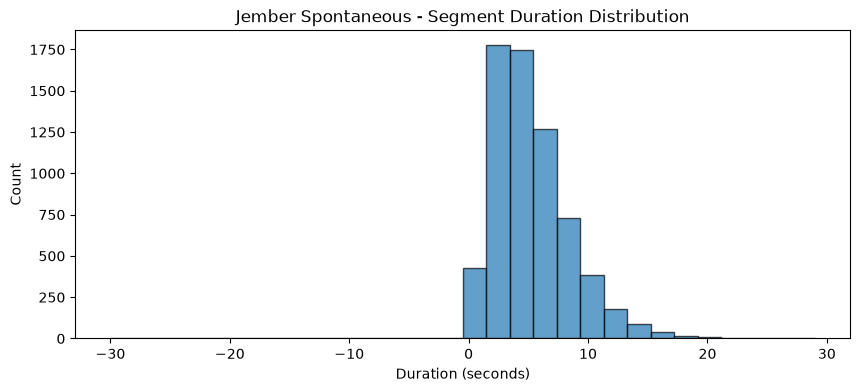


Segment duration analysis:
Total segments: 6679
Mean duration: 5.38s
Median duration: 5.00s
Min: -30.00s, Max: 29.00s


In [5]:
# Visualize the distribution of segment durations
# This histogram shows whether segments cluster in a certain range or are scattered across sizes
if "duration_s" in jember_df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(jember_df["duration_s"].dropna(), bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Count")
    ax.set_title(f"{DATASET_NAME} - Segment Duration Distribution")
    plt.show()
    
    # Print summary statistics about segment lengths
    print("\nSegment duration analysis:")
    print(f"Total segments: {len(jember_df)}")
    print(f"Mean duration: {jember_df['duration_s'].mean():.2f}s")
    print(f"Median duration: {jember_df['duration_s'].median():.2f}s")
    print(f"Min: {jember_df['duration_s'].min():.2f}s, Max: {jember_df['duration_s'].max():.2f}s")

## 5. Visualize Segment Duration Distribution

Plot histogram of segment durations to understand how speech segments are distributed in length. This helps identify if there are many very short/long segments which might indicate data quality issues.

In [6]:
# Check language distribution (Jember should be 100% Javanese)
if "language" in jember_df.columns:
    print("Language distribution:")
    print(jember_df["language"].value_counts())
else:
    print(f"Dataset is monolingual: {LANGUAGE}")

# Count and display speakers in the dataset
# More speakers = more speaker diversity, helps test speaker generalization
if "speaker_id" in jember_df.columns or "speaker" in jember_df.columns:
    speaker_col = "speaker_id" if "speaker_id" in jember_df.columns else "speaker"
    print(f"\nUnique speakers: {jember_df[speaker_col].nunique()}")
    print(jember_df[speaker_col].value_counts())

Dataset is monolingual: Javanese


## 6. Language and Speaker Metadata

Check language distribution (should be 100% Javanese) and analyze speaker counts. This helps understand speaker diversity in the dataset.

In [7]:
# Regex patterns for cleaning transcriptions
BRACKET_TAG_RE = re.compile(r"\[[^\]]*\]")  # [laugh], [cough], etc.
UNINTEL_RE = re.compile(r"\(\?\?\?\)")      # (???) for unintelligible
STRIP_PUNCT = ",?¿¡!\";:"                   # punctuation to remove
SENT_END = {".", "!", "?", "—"}             # sentence-ending markers

def handle_ellipses(text):
    """Preserve mid-word ellipses (...) but remove standalone ellipses."""
    protected = []
    def protect(m):
        protected.append(m.group(0))
        return f"\x00{len(protected)-1}\x00"
    text = re.sub(r"(?<=\S)\.{3,}", protect, text)
    text = re.sub(r"(?:(?<=\s)|^)\.{3,}(?=\s|$)", "", text)
    text = text.replace(".", "")
    for i, val in enumerate(protected):
        text = text.replace(f"\x00{i}\x00", val)
    return text

def lowercase_sentence_initial(text):
    """Lowercase the first letter of sentences (common in spontaneous speech)."""
    chars = list(text)
    n = len(chars)
    def is_acronym(i):
        return i+1 < n and chars[i].isupper() and chars[i+1].isupper()
    for i, c in enumerate(chars):
        if c.isalpha():
            if not is_acronym(i):
                chars[i] = c.lower()
            break
    i = 0
    while i < n:
        if chars[i] in SENT_END:
            j = i + 1
            while j < n and chars[j] == " ":
                j += 1
            if j < n and chars[j].isalpha() and not is_acronym(j):
                chars[j] = chars[j].lower()
        i += 1
    return "".join(chars)

def normalize(text):
    """Normalize transcription text: remove annotations, unreadable markers, normalize spacing."""
    if pd.isna(text):
        return ""
    text = BRACKET_TAG_RE.sub("", text)  # [laugh], [cough], etc.
    text = UNINTEL_RE.sub("", text)      # (???)
    text = lowercase_sentence_initial(text)
    text = handle_ellipses(text)
    for ch in STRIP_PUNCT:
        text = text.replace(ch, "")
    return re.sub(r"\s+", " ", text).strip()

# Test normalization on Javanese examples
print(f"Testing {LANGUAGE} text normalization:")
for t in ["aku [laugh] arep budhal (???) saiki.", "iso apa ora? terus piye?", "ya... ya ora ngerti."]:
    print(f"  {repr(t)} -> {repr(normalize(t))}")

Testing Javanese text normalization:
  'aku [laugh] arep budhal (???) saiki.' -> 'aku arep budhal saiki'
  'iso apa ora? terus piye?' -> 'iso apa ora terus piye'
  'ya... ya ora ngerti.' -> 'ya... ya ora ngerti'


## 7. Text Normalization

Define functions to normalize Javanese transcriptions. This removes annotation artifacts (like [laugh], (???)) and standardizes punctuation/capitalization. Critical for clean text analysis and vocabulary building.

In [8]:
# Build word frequency counter from text
def build_vocab(series):
    """Build word frequency counter from text series."""
    counter = Counter()
    for t in series:
        counter.update(normalize(t).split())
    return counter

# Identify which column contains transcription text
text_col = "text" if "text" in jember_df.columns else "transcript"
jember_vocab = build_vocab(jember_df[text_col])

# Display vocabulary statistics
print(f"\n{DATASET_NAME} Vocabulary Analysis")
print(f"Vocabulary size: {len(jember_vocab)} unique words")
print(f"Total words: {sum(jember_vocab.values())}")
print(f"\nMost common words:")
for word, count in jember_vocab.most_common(20):
    print(f"  {word}: {count}")


Jember Spontaneous Vocabulary Analysis


Vocabulary size: 7899 unique words
Total words: 65708

Most common words:
  ya: 2723
  iku: 2680
  ngono: 1452
  aku: 1413
  sing: 1348
  apa: 1198
  kan: 946
  gak: 910
  lèk: 813
  ndèk: 782
  těrus: 757
  kaya: 739
  dadi: 706
  iki: 704
  wis: 663
  e...: 626
  e: 614
  ana: 579
  nèk: 484
  isa: 454


## 8. Build Vocabulary from Transcriptions

Extract all unique words from normalized transcriptions and count their frequencies. This vocabulary will be used to assess data coverage and analyze word distribution patterns in Javanese speech.

In [9]:
# Analyze word frequency distribution to understand vocabulary characteristics
print(f"\n{DATASET_NAME} Vocabulary Coverage:")
print(f"Unique word types: {len(jember_vocab)}")
print(f"Words with freq >= 5: {sum(1 for w in jember_vocab.values() if w >= 5)}")
print(f"Words with freq >= 10: {sum(1 for w in jember_vocab.values() if w >= 10)}")

# Hapax legomena are words that appear only once
# High percentage of hapax may indicate typos, rare words, or transcription errors
hapax = sum(1 for w in jember_vocab.values() if w == 1)
print(f"Hapax legomena (freq=1): {hapax} ({hapax/len(jember_vocab)*100:.1f}%)")

# Show word frequency distribution: how many words appear 1x, 2x, 3x, etc.
print(f"\nWord frequency distribution:")
freq_dist = Counter(jember_vocab.values())
for freq in sorted(freq_dist.keys())[:10]:
    print(f"  Frequency {freq}: {freq_dist[freq]} words")


Jember Spontaneous Vocabulary Coverage:
Unique word types: 7899
Words with freq >= 5: 1561
Words with freq >= 10: 802
Hapax legomena (freq=1): 4160 (52.7%)

Word frequency distribution:
  Frequency 1: 4160 words
  Frequency 2: 1208 words
  Frequency 3: 622 words
  Frequency 4: 348 words
  Frequency 5: 248 words
  Frequency 6: 182 words
  Frequency 7: 133 words
  Frequency 8: 102 words
  Frequency 9: 94 words
  Frequency 10: 72 words


## 9. Analyze Vocabulary Coverage

Compute statistics about word frequency distribution. Identifies rare words (hapax legomena) and computes vocabulary density. High percentage of rare words can indicate typos or annotation errors.

In [10]:
# Detect which columns contain speaker and conversation IDs
# Different metadata formats may use different column names
speaker_col = None
convo_col = None

if "speaker_id" in jember_df.columns:
    speaker_col = "speaker_id"
elif "speaker" in jember_df.columns:
    speaker_col = "speaker"

if "convo_id" in jember_df.columns:
    convo_col = "convo_id"
elif "conversation_id" in jember_df.columns:
    convo_col = "conversation_id"

# Display speaker statistics
# Uneven speaker distribution can bias models
if speaker_col:
    print(f"\nSpeaker Statistics:")
    print(f"Unique speakers: {jember_df[speaker_col].nunique()}")
    print(f"\nSegments per speaker:")
    print(jember_df[speaker_col].value_counts())

# Display conversation statistics
# More conversations = more diverse speaking contexts and topics
if convo_col:
    print(f"\n\nConversation Statistics:")
    print(f"Unique conversations: {jember_df[convo_col].nunique()}")
    print(f"\nSegments per conversation:")
    print(jember_df[convo_col].value_counts())

## 10. Speaker and Conversation Statistics

Analyze how segments are distributed across speakers and conversations. Uneven distribution can bias models toward certain speakers. More conversations = more diverse speaking contexts.

In [11]:
# Detect empty transcriptions (missing or blank text)
text_col = "text" if "text" in jember_df.columns else "transcript"
empty = jember_df[text_col].isna() | (jember_df[text_col].astype(str).str.strip() == "")
print(f"\nData Quality Check:")
print(f"Empty transcriptions: {empty.sum()}/{len(jember_df)} ({empty.sum()/len(jember_df)*100:.1f}%)")

# Compute word count for each segment after normalization
jember_df["word_count"] = jember_df[text_col].fillna("").apply(
    lambda t: len(normalize(t).split()) if normalize(t) else 0
)

# If we have duration info, compute speech rate (words per second)
# Very high speech rates (>5 wps) usually indicate segmentation/transcription errors
if "duration_s" in jember_df.columns:
    jember_df["words_per_sec"] = jember_df["word_count"] / jember_df["duration_s"].replace(0, np.nan)
    
    print(f"\nWord count statistics:")
    print(jember_df["word_count"].describe())
    print(f"\nSpeech rate (words/sec):")
    print(jember_df["words_per_sec"].describe())
    
    # Flag anomalies - high speech rate typically indicates segmentation/transcription errors
    print(f"\nAnomalies - High speech rate (>5 words/sec):")
    anomalies = jember_df[jember_df["words_per_sec"] > 5].sort_values("words_per_sec", ascending=False)
    if len(anomalies) > 0:
        print(anomalies[[text_col, "duration_s", "word_count", "words_per_sec"]].head(10))
    else:
        print("None detected")


Data Quality Check:
Empty transcriptions: 0/6679 (0.0%)



Word count statistics:
count    6679.000000
mean        9.838000
std         5.689646
min         1.000000
25%         6.000000
50%         9.000000
75%        13.000000
max        48.000000
Name: word_count, dtype: float64

Speech rate (words/sec):
count    6641.000000
mean        1.991633
std         0.811252
min        -8.000000
25%         1.500000
50%         2.000000
75%         2.400000
max        10.000000
Name: words_per_sec, dtype: float64

Anomalies - High speech rate (>5 words/sec):
                                                   text  duration_s  \
1471  Ibu pertanyaan yang pertama, kados pundi kegia...         1.0   
2036                     Ya, kan lèk urip ning omah ya,         1.0   
388                Wah, wis otomatis tuku ndèk anu aku.         1.0   
276                      Sik, sik akèh digae ndèk kene.         1.0   
2105                  Ya, wis nggak usah ngomong ngono.         1.0   
6129                    Těrus mudune iku pisan ya sara.         1.0   
58

## 11. Data Quality Checks

Identify transcription issues: empty transcriptions, unusually high speech rates (indicating segmentation errors), and outliers. These quality metrics help diagnose potential problems in the dataset.

In [12]:
# Print comprehensive dataset summary
# This serves as a quick reference for the dataset's characteristics
print(f"\n{'='*60}")
print(f"{DATASET_NAME} Dataset Summary")
print(f"{'='*60}")
print(f"Language: {LANGUAGE}")
print(f"Total segments: {len(jember_df)}")
print(f"Total vocabulary: {len(jember_vocab)} unique words")
print(f"Total word tokens: {sum(jember_vocab.values())}")

# Audio duration info if available
if "duration_s" in jember_df.columns:
    total_duration = jember_df["duration_s"].sum()
    hours = total_duration / 3600
    print(f"Total audio duration: {total_duration:.1f}s ({hours:.2f} hours)")

# Speaker info if available
if speaker_col:
    print(f"Number of speakers: {jember_df[speaker_col].nunique()}")
# Conversation info if available
if convo_col:
    print(f"Number of conversations: {jember_df[convo_col].nunique()}")
    
print(f"{'='*60}")


Jember Spontaneous Dataset Summary
Language: Javanese
Total segments: 6679
Total vocabulary: 7899 unique words
Total word tokens: 65708
Total audio duration: 35906.0s (9.97 hours)


## 12. Dataset Summary

Generate a comprehensive summary of the Jember Javanese spontaneous speech dataset. This provides a high-level overview of dataset size, coverage, and composition that can be used for documentation and comparison with other datasets.

---

# Part 2 — Competition-Targeted EDA

Part 1 characterised the Jember training corpus in isolation. That is not the question the
competition asks. The competition scores us on the **hidden test set**, and our only honest proxy
for it is the **official development set** (`indonesian_dev/`), which is drawn from the same
underlying collection.

So every analysis below is framed as one question:

> **How is Jember (what we train on) different from the dev set (what we are scored on),
> and what does each difference cost us in Word Error Rate?**

Sections:

| # | Section | Question it answers |
|---|---------|---------------------|
| 13 | Scorer-compatible normaliser | Are we measuring what the organisers measure? |
| 14 | Dev set load + audio probe | What does the target distribution actually look like? |
| 15 | Jember integrity audit | Which training rows are broken? |
| 16 | Duration domain gap | Do our training clips look like test clips? |
| 17 | Re-segmentation simulation | Can we close that gap for free? |
| 18 | Vocabulary & OOV | What is our lexical ceiling? |
| 19 | Orthography / diacritics | Are we spelling words the way the scorer expects? |
| 20 | Disfluency & markup | Do we model conversational phenomena? |
| 21 | Casing & acronyms | Are we losing points to capitalisation? |
| 22 | Whisper 30s window | Will long clips be silently truncated? |
| 23 | Synthesis | What does all of this mean, and what do we do? |

## 13. Scorer-Compatible Text Normalisation

WER is computed **after** normalisation, so the normaliser *is* part of the metric. Section 8 of the
project brief specifies the official behaviour. The subtle part, and the part most teams get wrong:

> The normaliser **does not simply lowercase everything.** It lowercases only *sentence-initial*
> letters, protects acronyms, and keeps word-attached ellipses because they encode disfluency.

Casing everywhere else is compared **as written**. That means `SMP` vs `smp` is a substitution error.
We re-implement it here as `wer_norm()` and use it for every measurement in Part 2, so our local
numbers move in the same direction as the leaderboard.

In [13]:
import unicodedata
from collections import Counter, defaultdict

BRACKET_TAG_RE = re.compile(r"\[[^\]]*\]")            # [laugh], [cough]
UNINTEL_RE     = re.compile(r"\(\?\?\?\)|\[\?\?\?\]")  # (???) and [???]
SCORER_PUNCT   = ',?¿¡!";:'                  # removed by the official scorer
SENT_END       = {".", "!", "?", "\u2014"}

def _is_acronym(chars, i):
    """Two or more consecutive capitals => acronym, protected from lowercasing."""
    n = len(chars)
    return i + 1 < n and chars[i].isupper() and chars[i + 1].isupper()

def _lowercase_sentence_initial(text):
    chars, n = list(text), len(text)
    for i, c in enumerate(chars):            # first alphabetic char of the transcript
        if c.isalpha():
            if not _is_acronym(chars, i):
                chars[i] = c.lower()
            break
    for i in range(n):                       # first alphabetic char after . ! ? em-dash
        if chars[i] in SENT_END:
            j = i + 1
            while j < n and chars[j] == " ":
                j += 1
            if j < n and chars[j].isalpha() and not _is_acronym(chars, j):
                chars[j] = chars[j].lower()
    return "".join(chars)

def _handle_ellipses(text):
    """Keep word-attached ellipses (disfluency), drop standalone ones and all other periods."""
    kept = []
    def protect(m):
        kept.append(m.group(0))
        return f"\x00{len(kept)-1}\x00"
    text = re.sub(r"(?<=\S)\.{3,}", protect, text)
    text = re.sub(r"(?:(?<=\s)|^)\.{3,}(?=\s|$)", "", text)
    text = text.replace(".", "")
    for i, v in enumerate(kept):
        text = text.replace(f"\x00{i}\x00", v)
    return text

def wer_norm(text):
    """Approximation of the official competition normaliser."""
    if pd.isna(text):
        return ""
    t = BRACKET_TAG_RE.sub("", str(t_ := text))
    t = UNINTEL_RE.sub("", t)
    t = _lowercase_sentence_initial(t)
    t = _handle_ellipses(t)
    for ch in SCORER_PUNCT:
        t = t.replace(ch, "")
    return re.sub(r"\s+", " ", t).strip()

def toks(text):
    return wer_norm(text).split()

# Sanity checks that encode the tricky rules explicitly
checks = [
    ("Aku [laugh] arep budhal (???) saiki.", "casing + tags + trailing period"),
    ("SMP iku angel. Aku ora ngerti.",       "SMP must stay uppercase; 'Aku' after '.' lowercased"),
    ("ya... ya e... ora ngerti",             "word-attached ellipsis kept, standalone dropped"),
]
print("Scorer normalisation checks")
for raw, why in checks:
    print(f"  {why}\n    in : {raw!r}\n    out: {wer_norm(raw)!r}")


Scorer normalisation checks
  casing + tags + trailing period
    in : 'Aku [laugh] arep budhal (???) saiki.'
    out: 'aku arep budhal saiki'
  SMP must stay uppercase; 'Aku' after '.' lowercased
    in : 'SMP iku angel. Aku ora ngerti.'
    out: 'SMP iku angel aku ora ngerti'
  word-attached ellipsis kept, standalone dropped
    in : 'ya... ya e... ora ngerti'
    out: 'ya... ya e... ora ngerti'


### Word Error Rate

We implement WER by Levenshtein alignment over normalised tokens. It is the objective, so we want it
available from the first cell onward — including the per-language breakdown the brief insists on.

In [14]:
def wer_counts(ref, hyp):
    """Levenshtein alignment over token lists -> (substitutions, deletions, insertions, n_ref)."""
    r, h = toks(ref), toks(hyp)
    n, m = len(r), len(h)
    # d[i][j] = (cost, sub, del, ins)
    d = [[(0, 0, 0, 0)] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1):
        d[i][0] = (i, 0, i, 0)
    for j in range(1, m + 1):
        d[0][j] = (j, 0, 0, j)
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if r[i - 1] == h[j - 1]:
                d[i][j] = d[i - 1][j - 1]
            else:
                c_s, c_d, c_i = d[i-1][j-1][0], d[i-1][j][0], d[i][j-1][0]
                best = min(c_s, c_d, c_i)
                if best == c_s:
                    p = d[i-1][j-1]; d[i][j] = (best + 1, p[1] + 1, p[2], p[3])
                elif best == c_d:
                    p = d[i-1][j];   d[i][j] = (best + 1, p[1], p[2] + 1, p[3])
                else:
                    p = d[i][j-1];   d[i][j] = (best + 1, p[1], p[2], p[3] + 1)
    s, dl, ins = d[n][m][1], d[n][m][2], d[n][m][3]
    return s, dl, ins, n

def wer(refs, hyps):
    """Corpus-level WER: total edits / total reference words (NOT the mean of per-clip WERs)."""
    S = D = I = N = 0
    for r, h in zip(refs, hyps):
        s, dl, i_, n = wer_counts(r, h)
        S += s; D += dl; I += i_; N += n
    return (S + D + I) / N if N else float("nan"), dict(sub=S, dele=D, ins=I, n_ref=N)

# Verify against the example in the brief: "running" vs "run" is one substitution.
print("WER('running','run') =", wer(["running"], ["run"])[0], "(expected 1.0)")
print("WER identical        =", wer(["aku arep budhal"], ["aku arep budhal"])[0], "(expected 0.0)")
print("WER one deletion     =", round(wer(["aku arep budhal"], ["aku arep"])[0], 4), "(expected 0.3333)")


WER('running','run') = 1.0 (expected 1.0)
WER identical        = 0.0 (expected 0.0)
WER one deletion     = 0.3333 (expected 0.3333)


## 14. Load the Official Development Set

The dev set is **validation only** — never training data. It is our single best estimate of the
hidden test distribution, so we characterise it carefully.

The brief describes three `language` values (`jav`, `ind`, `javind`). The first thing worth checking
is whether all three actually appear.

In [15]:
DEV_DIR   = Path("indonesian_dev")
DEV_TSV   = DEV_DIR / "metadata.tsv"
DEV_CLIPS = DEV_DIR / "clips"

dev_df = pd.read_csv(DEV_TSV, sep="\t")
print(f"Development set: {dev_df.shape[0]} clips, columns = {dev_df.columns.tolist()}")

print("\nLanguage distribution (the label the brief tells us to break WER down by):")
lang_counts = dev_df["language"].value_counts()
for lang, n in lang_counts.items():
    print(f"  {lang:8s} {n:4d} clips  ({n/len(dev_df)*100:5.1f}%)")

for expected in ["jav", "ind", "javind"]:
    if expected not in lang_counts.index:
        print(f"  {expected:8s}    0 clips  (  0.0%)   <-- ABSENT from the dev set")

print("\nSpeakers x language:")
print(pd.crosstab(dev_df["speaker"], dev_df["language"]))
print("\nConversations x language:")
print(pd.crosstab(dev_df["convo_id"], dev_df["language"]))


Development set: 372 clips, columns = ['audio_filename', 'speaker', 'transcript', 'language', 'convo_id']

Language distribution (the label the brief tells us to break WER down by):
  javind    352 clips  ( 94.6%)
  ind        20 clips  (  5.4%)
  jav         0 clips  (  0.0%)   <-- ABSENT from the dev set

Speakers x language:
language  ind  javind
speaker              
1           0     140
5           7      27
6           0     154
7          13      31

Conversations x language:
language  ind  javind
convo_id             
2          20      58
5           0     294


### Probe every dev clip's audio

Sample rate, channel count and duration drive the whole preprocessing contract. We read them from
the files rather than trusting the brief.

In [16]:
def probe(path):
    """Return (duration_s, samplerate, channels) or NaNs if unreadable."""
    try:
        i = sf.info(str(path))
        return i.frames / i.samplerate, i.samplerate, i.channels
    except Exception:
        return np.nan, np.nan, np.nan

probes = [probe(DEV_CLIPS / f) for f in dev_df["audio_filename"]]
dev_df[["duration_s", "sr", "channels"]] = pd.DataFrame(probes, index=dev_df.index)

dev_df["n_words"] = dev_df["transcript"].apply(lambda t: len(toks(t)))
dev_df["wps"]     = dev_df["n_words"] / dev_df["duration_s"]

print("DEV AUDIO")
print(f"  unreadable clips : {dev_df['duration_s'].isna().sum()}")
print(f"  sample rates     : {dev_df['sr'].value_counts().to_dict()}")
print(f"  channels         : {dev_df['channels'].value_counts().to_dict()}")
print(f"  total duration   : {dev_df['duration_s'].sum()/3600:.2f} h")
print(f"  duration  mean {dev_df['duration_s'].mean():5.1f}s  median {dev_df['duration_s'].median():5.1f}s  "
      f"min {dev_df['duration_s'].min():4.1f}s  max {dev_df['duration_s'].max():5.1f}s")
print(f"  reference words  : {dev_df['n_words'].sum():,}  (this is the WER denominator)")
print(f"  words/clip  mean {dev_df['n_words'].mean():.1f}  median {dev_df['n_words'].median():.0f}")
print(f"  speech rate mean {dev_df['wps'].mean():.2f} w/s")

print("\nOne WER point on this dev set is worth "
      f"{dev_df['n_words'].sum()/100:.0f} word errors -- small changes are noisy.")


DEV AUDIO
  unreadable clips : 0
  sample rates     : {48000: 372}
  channels         : {1: 372}
  total duration   : 2.56 h
  duration  mean  24.8s  median  26.2s  min  6.3s  max  37.8s
  reference words  : 17,473  (this is the WER denominator)
  words/clip  mean 47.0  median 48
  speech rate mean 1.89 w/s

One WER point on this dev set is worth 175 word errors -- small changes are noisy.


## 15. Jember Integrity Audit

Before we train on 6,679 rows we need to know how many are actually usable. We check timestamp
validity, timestamp *resolution*, overruns past the end of the audio, and the true sample-rate mix.

In [17]:
JEMBER_AUDIO = Path(JEMBER_AUDIO_DIR)

# --- audio file inventory -------------------------------------------------
jember_files = {}
unreadable   = []
for p in sorted(JEMBER_AUDIO.glob("*.mp3")):
    dur, sr, ch = probe(p)
    if np.isnan(dur):
        unreadable.append(p.name)
    else:
        jember_files[int(p.stem)] = (dur, sr, ch)

file_sr = pd.Series({k: v[1] for k, v in jember_files.items()})
file_ch = pd.Series({k: v[2] for k, v in jember_files.items()})
file_du = pd.Series({k: v[0] for k, v in jember_files.items()})

print("JEMBER AUDIO FILES")
print(f"  sessions on disk : {len(jember_files)}   unreadable: {len(unreadable)}")
print(f"  sample rates     : {file_sr.value_counts().to_dict()}   <-- brief claims 44.1 kHz only")
print(f"  channels         : {file_ch.value_counts().to_dict()}")
print(f"  total audio      : {file_du.sum()/3600:.2f} h")
print(f"  session length   : median {file_du.median():.0f}s  max {file_du.max():.0f}s")

# --- timestamp integrity --------------------------------------------------
jember_df["file_duration_s"] = jember_df["Audio file name"].map(lambda k: jember_files.get(k, (np.nan,))[0])
jember_df["overrun_s"]       = jember_df["end_s"] - jember_df["file_duration_s"]

neg   = jember_df["duration_s"] < 0
zero  = jember_df["duration_s"] == 0
tiny  = (jember_df["duration_s"] > 0) & (jember_df["duration_s"] < 0.5)
over  = jember_df["overrun_s"] > 0.5
blank = jember_df["text"].fillna("").str.strip() == ""

print("\nSEGMENT INTEGRITY (of %d rows)" % len(jember_df))
for label, mask in [("negative duration (end < start)", neg), ("zero duration", zero),
                    ("< 0.5 s", tiny), ("end beyond file length", over), ("blank transcript", blank)]:
    print(f"  {label:34s} {mask.sum():4d}")

bad_rows = neg | zero | blank
print(f"  --> unusable rows: {bad_rows.sum()} ({bad_rows.sum()/len(jember_df)*100:.2f}%), "
      f"{(~bad_rows).sum()} usable")

# --- timestamp resolution -------------------------------------------------
frac = ((jember_df["start_s"] % 1 != 0).sum() + (jember_df["end_s"] % 1 != 0).sum())
print(f"\nTIMESTAMP RESOLUTION")
print(f"  non-integer timestamp values: {frac} / {2*len(jember_df)}")
print(f"  --> timestamps are quantised to WHOLE SECONDS: {frac == 0}")

# --- missing / orphan sessions -------------------------------------------
referenced = set(jember_df["Audio file name"]); on_disk = set(jember_files)
print(f"\n  sessions referenced but missing : {sorted(referenced - on_disk) or 'none'}")
print(f"  audio files never referenced    : {sorted(on_disk - referenced) or 'none'}")

jember_clean = jember_df[~bad_rows].copy()
print(f"\njember_clean: {len(jember_clean)} segments, {jember_clean['duration_s'].sum()/3600:.2f} h")


JEMBER AUDIO FILES
  sessions on disk : 208   unreadable: 0
  sample rates     : {48000: 119, 44100: 89}   <-- brief claims 44.1 kHz only
  channels         : {1: 208}
  total audio      : 10.03 h
  session length   : median 100s  max 1203s

SEGMENT INTEGRITY (of 6679 rows)
  negative duration (end < start)       3
  zero duration                        38
  < 0.5 s                               0
  end beyond file length                4
  blank transcript                      0
  --> unusable rows: 41 (0.61%), 6638 usable

TIMESTAMP RESOLUTION
  non-integer timestamp values: 0 / 13358
  --> timestamps are quantised to WHOLE SECONDS: True

  sessions referenced but missing : none
  audio files never referenced    : none

jember_clean: 6638 segments, 9.98 h


### Why whole-second timestamps matter

Every Jember boundary is rounded to a whole second, but the brief says the corpus was segmented by
hand. A boundary can therefore sit up to ~0.5 s away from the true speech edge in either direction —
cutting the first or last syllable off a word, or pulling in a neighbouring one.

At a median segment length of 5 s, a ±0.5 s error is **10% of the clip**. This is the strongest
argument for the re-segmentation strategy in Section 17: merging adjacent segments moves every
boundary error to the *outside* of a much longer chunk, where it is proportionally negligible.

In [18]:
edge_risk = 0.5 / jember_clean["duration_s"]
print("Boundary error as a share of clip length (assuming +/-0.5 s rounding):")
print(f"  median clip: {edge_risk.median()*100:5.1f}% of the clip is boundary-uncertain")
print(f"  clips where +/-0.5s exceeds 10% of the clip: "
      f"{(edge_risk > 0.10).sum():4d} ({(edge_risk > 0.10).mean()*100:.1f}%)")
print(f"  clips <= 2 s (severe risk): {(jember_clean['duration_s'] <= 2).sum()} "
      f"({(jember_clean['duration_s'] <= 2).mean()*100:.1f}%)")


Boundary error as a share of clip length (assuming +/-0.5 s rounding):
  median clip:  10.0% of the clip is boundary-uncertain
  clips where +/-0.5s exceeds 10% of the clip: 3095 (46.6%)
  clips <= 2 s (severe risk): 1182 (17.8%)


## 16. The Duration Domain Gap

This is the first of the three big mismatches. Whisper — and any encoder-decoder ASR model — behaves
differently on a 5-second clip than on a 26-second one: attention spans, decoder length priors, and
repetition dynamics all change with input length.

If we fine-tune on 5-second clips and infer on 26-second clips, we are testing the model
**out of distribution on the axis it is most sensitive to**.

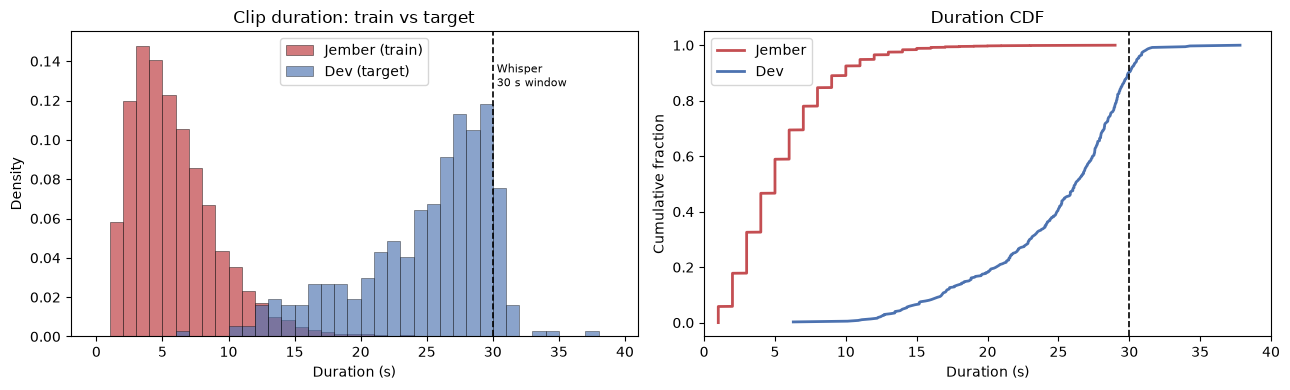

                           Jember        Dev
mean duration (s)            5.42      24.79
median duration (s)          5.00      26.21
mean words/clip              9.88      46.97
mean words/second            1.99       1.89

Share of Jember clips inside the dev duration band (15-32 s): 1.6%
Share of dev clips in that band:                              92.7%
Dev median / Jember median = 5.2x


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(jember_clean["duration_s"], bins=np.arange(0, 40, 1),
             alpha=.75, color="#c44e52", edgecolor="black", linewidth=.4, density=True, label="Jember (train)")
axes[0].hist(dev_df["duration_s"].dropna(), bins=np.arange(0, 40, 1),
             alpha=.65, color="#4c72b0", edgecolor="black", linewidth=.4, density=True, label="Dev (target)")
axes[0].axvline(30, color="black", ls="--", lw=1.2)
axes[0].text(30.3, axes[0].get_ylim()[1]*.82, "Whisper\n30 s window", fontsize=8)
axes[0].set_xlabel("Duration (s)"); axes[0].set_ylabel("Density")
axes[0].set_title("Clip duration: train vs target"); axes[0].legend()

for lbl, s, c in [("Jember", jember_clean["duration_s"], "#c44e52"),
                  ("Dev", dev_df["duration_s"].dropna(), "#4c72b0")]:
    xs = np.sort(s.values)
    axes[1].plot(xs, np.arange(1, len(xs)+1)/len(xs), label=lbl, color=c, lw=2)
axes[1].axvline(30, color="black", ls="--", lw=1.2)
axes[1].set_xlabel("Duration (s)"); axes[1].set_ylabel("Cumulative fraction")
axes[1].set_title("Duration CDF"); axes[1].legend(); axes[1].set_xlim(0, 40)
plt.tight_layout(); plt.show()

print(f"{'':22s} {'Jember':>10s} {'Dev':>10s}")
for label, a, b in [
    ("mean duration (s)",   jember_clean['duration_s'].mean(),   dev_df['duration_s'].mean()),
    ("median duration (s)", jember_clean['duration_s'].median(), dev_df['duration_s'].median()),
    ("mean words/clip",     jember_clean['word_count'].mean(),   dev_df['n_words'].mean()),
    ("mean words/second",   (jember_clean['word_count']/jember_clean['duration_s']).mean(), dev_df['wps'].mean()),
]:
    print(f"{label:22s} {a:10.2f} {b:10.2f}")

overlap = ((jember_clean["duration_s"] >= 15) & (jember_clean["duration_s"] <= 32)).mean()
print(f"\nShare of Jember clips inside the dev duration band (15-32 s): {overlap*100:.1f}%")
print(f"Share of dev clips in that band:                              "
      f"{((dev_df['duration_s']>=15)&(dev_df['duration_s']<=32)).mean()*100:.1f}%")
print(f"Dev median / Jember median = {dev_df['duration_s'].median()/jember_clean['duration_s'].median():.1f}x")


## 17. Re-Segmentation: Closing the Gap for Free

The fix depends on one empirical question: **are Jember's segments contiguous?** If consecutive
segments in a session are back-to-back with no gaps, we can concatenate them into longer
pseudo-utterances whose transcripts are simply the concatenated texts — no new labelling, no new
audio, no loss of data.

We measure the gaps, then simulate the merge.

GAPS BETWEEN CONSECUTIVE SEGMENTS
  n = 6430   median = 0.00s   mean = -0.00s
  exactly zero : 100.0%
  <= 1 s       : 100.0%
  negative (overlap): 2
  --> segments are contiguous, so merging is lossless

MERGED PSEUDO-UTTERANCES
  count      : 1473  (from 6638 raw segments)
  total audio: 9.98 h  (raw: 9.98 h -- nothing lost)
  duration   : mean 24.4s  median 26.0s
  words/clip : mean 44.5  median 46
  segs merged per chunk: median 4

Share inside the dev duration band (15-32 s)
  raw Jember      :   1.6%
  merged Jember   :  92.5%
  dev (target)    :  92.7%

merged median 26.0s  vs  dev median 26.2s
merged mean   24.4s  vs  dev mean   24.8s


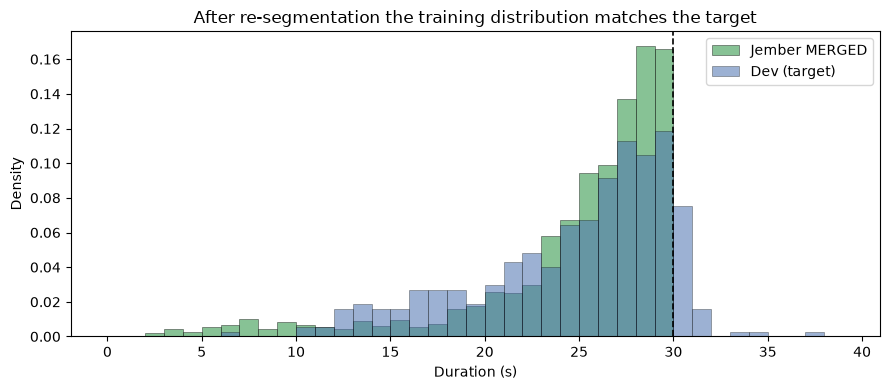

In [20]:
seg = jember_clean.sort_values(["Audio file name", "start_s"])
gaps = []
for _, g in seg.groupby("Audio file name"):
    gaps.extend((g["start_s"].values[1:] - g["end_s"].values[:-1]).tolist())
gaps = np.array(gaps)

print("GAPS BETWEEN CONSECUTIVE SEGMENTS")
print(f"  n = {len(gaps)}   median = {np.median(gaps):.2f}s   mean = {gaps.mean():.2f}s")
print(f"  exactly zero : {(gaps == 0).mean()*100:.1f}%")
print(f"  <= 1 s       : {(gaps <= 1).mean()*100:.1f}%")
print(f"  negative (overlap): {(gaps < 0).sum()}")
print("  --> segments are contiguous, so merging is lossless\n")

def merge_segments(df, max_dur=29.0, max_gap=1.0):
    """Concatenate consecutive same-session segments into <=max_dur pseudo-utterances."""
    out = []
    for sess, g in df.sort_values(["Audio file name", "start_s"]).groupby("Audio file name"):
        cs = ce = None; parts = []
        for s, e, t in zip(g["start_s"], g["end_s"], g["text"]):
            if cs is None:
                cs, ce, parts = s, e, [str(t)]
            elif (e - cs) <= max_dur and (s - ce) <= max_gap:
                ce = e; parts.append(str(t))
            else:
                out.append((sess, cs, ce, ce - cs, " ".join(parts), len(parts)))
                cs, ce, parts = s, e, [str(t)]
        if cs is not None:
            out.append((sess, cs, ce, ce - cs, " ".join(parts), len(parts)))
    return pd.DataFrame(out, columns=["session", "start_s", "end_s", "duration_s", "text", "n_source_segs"])

merged = merge_segments(jember_clean)
merged["n_words"] = merged["text"].apply(lambda t: len(toks(t)))

print("MERGED PSEUDO-UTTERANCES")
print(f"  count      : {len(merged)}  (from {len(jember_clean)} raw segments)")
print(f"  total audio: {merged['duration_s'].sum()/3600:.2f} h  (raw: {jember_clean['duration_s'].sum()/3600:.2f} h -- nothing lost)")
print(f"  duration   : mean {merged['duration_s'].mean():.1f}s  median {merged['duration_s'].median():.1f}s")
print(f"  words/clip : mean {merged['n_words'].mean():.1f}  median {merged['n_words'].median():.0f}")
print(f"  segs merged per chunk: median {merged['n_source_segs'].median():.0f}")

band = lambda s: ((s >= 15) & (s <= 32)).mean() * 100
print(f"\nShare inside the dev duration band (15-32 s)")
print(f"  raw Jember      : {band(jember_clean['duration_s']):5.1f}%")
print(f"  merged Jember   : {band(merged['duration_s']):5.1f}%")
print(f"  dev (target)    : {band(dev_df['duration_s'].dropna()):5.1f}%")
print(f"\nmerged median {merged['duration_s'].median():.1f}s  vs  dev median {dev_df['duration_s'].median():.1f}s")
print(f"merged mean   {merged['duration_s'].mean():.1f}s  vs  dev mean   {dev_df['duration_s'].mean():.1f}s")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(merged["duration_s"], bins=np.arange(0, 40, 1), alpha=.7, density=True,
        color="#55a868", edgecolor="black", linewidth=.4, label="Jember MERGED")
ax.hist(dev_df["duration_s"].dropna(), bins=np.arange(0, 40, 1), alpha=.55, density=True,
        color="#4c72b0", edgecolor="black", linewidth=.4, label="Dev (target)")
ax.axvline(30, color="black", ls="--", lw=1.2)
ax.set_xlabel("Duration (s)"); ax.set_ylabel("Density")
ax.set_title("After re-segmentation the training distribution matches the target")
ax.legend(); plt.tight_layout(); plt.show()


## 18. Vocabulary and the OOV Ceiling

A word the model has never seen in fine-tuning is a word it will probably get wrong. The share of
dev tokens absent from the Jember vocabulary is therefore a rough **floor** on achievable WER from
Jember-only training — softened by Whisper's multilingual pretraining, which already knows a lot of
Indonesian, but real.

This is also where we find out *which language* each corpus actually is.

VOCABULARY
  Jember :  7,890 types    65,614 tokens
  Dev    :  3,273 types    17,473 tokens
  shared :  1,353 types  (41.3% of dev types)

  DEV TOKEN COVERAGE by Jember vocabulary : 78.6%
  OOV token rate (approx. lexical WER floor): 21.4%
  OOV: 1,920 types / 3,734 tokens

Most frequent words -- note which LANGUAGE each corpus is:
  Jember: ['ya', 'iku', 'ngono', 'aku', 'sing', 'apa', 'kan', 'gak', 'lèk', 'ndèk', 'těrus', 'kaya', 'dadi', 'iki', 'wis', 'e...', 'e', 'ana']
  Dev   : ['ya', 'aku', 'itu', 'yang', 'jadi', 'di', 'dan', 'gitu', 'terus', 'juga', 'nah', 'tuh', 'ada', 'kayak', 'banget', 'ini', 'gak', 'pas']

Function-word signature (share of all tokens):
               Javanese   Indonesian
  Jember         21.57%        3.13%
  Dev             5.23%       15.21%

Top dev words MISSING from Jember (each is a likely error):
   ['terus', 'kayaknya', 'suka', 'PR', 'ngerjain', "'kan", 'kui', 'soalnya', 'yo', 'sendiri', 'bareng', 'seneng', 'ono', 'iso', 'pergi', 'ataupun', 'dapat'

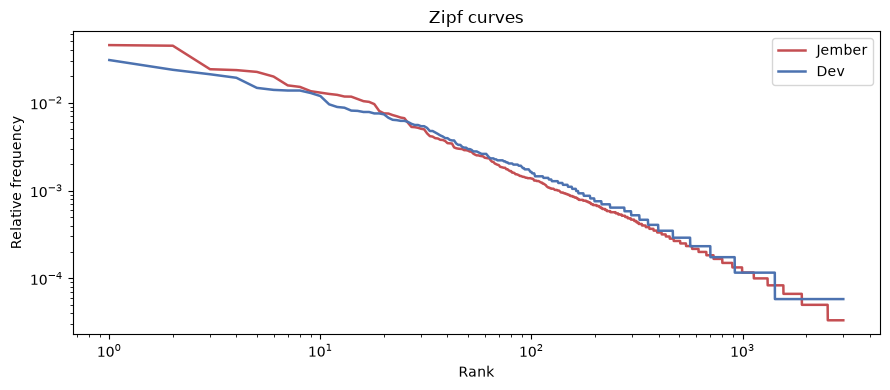

In [21]:
jember_vocab_c = Counter()
for t in jember_clean["text"]:
    jember_vocab_c.update(toks(t))
dev_vocab_c = Counter()
for t in dev_df["transcript"]:
    dev_vocab_c.update(toks(t))

j_tok, d_tok = sum(jember_vocab_c.values()), sum(dev_vocab_c.values())
shared = set(jember_vocab_c) & set(dev_vocab_c)
covered = sum(c for w, c in dev_vocab_c.items() if w in jember_vocab_c)
oov = Counter({w: c for w, c in dev_vocab_c.items() if w not in jember_vocab_c})

print("VOCABULARY")
print(f"  Jember : {len(jember_vocab_c):6,d} types   {j_tok:7,d} tokens")
print(f"  Dev    : {len(dev_vocab_c):6,d} types   {d_tok:7,d} tokens")
print(f"  shared : {len(shared):6,d} types  ({len(shared)/len(dev_vocab_c)*100:.1f}% of dev types)")
print(f"\n  DEV TOKEN COVERAGE by Jember vocabulary : {covered/d_tok*100:.1f}%")
print(f"  OOV token rate (approx. lexical WER floor): {100-covered/d_tok*100:.1f}%")
print(f"  OOV: {len(oov):,} types / {sum(oov.values()):,} tokens")

print("\nMost frequent words -- note which LANGUAGE each corpus is:")
jt = [w for w, _ in jember_vocab_c.most_common(18)]
dt = [w for w, _ in dev_vocab_c.most_common(18)]
print(f"  Jember: {jt}")
print(f"  Dev   : {dt}")

# Function words are the fingerprint of the matrix language of a corpus.
JAV = {"iku","sing","ngono","lèk","nèk","ndèk","iki","wis","ana","ora","aku","kowe","dhewe",
       "isa","iso","opo","apa","karo","neng","nèng","yo","kui","ono","meneh","akeh","akèh","kabeh","kabèh"}
IND = {"itu","yang","jadi","di","dan","ini","ada","tidak","saya","kamu","sendiri","bisa",
       "apa","dengan","ke","juga","sudah","akan","untuk","dari","pada","lagi","banyak","semua"}
def share(counter, lex):
    tot = sum(counter.values())
    return sum(c for w, c in counter.items() if w.lower() in lex) / tot * 100
print("\nFunction-word signature (share of all tokens):")
print(f"  {'':10s} {'Javanese':>10s} {'Indonesian':>12s}")
print(f"  {'Jember':10s} {share(jember_vocab_c, JAV):9.2f}% {share(jember_vocab_c, IND):11.2f}%")
print(f"  {'Dev':10s} {share(dev_vocab_c, JAV):9.2f}% {share(dev_vocab_c, IND):11.2f}%")

print("\nTop dev words MISSING from Jember (each is a likely error):")
print("  ", [w for w, _ in oov.most_common(30)])

fig, ax = plt.subplots(figsize=(9, 4))
ranks = np.arange(1, 3001)
for lbl, c, col in [("Jember", jember_vocab_c, "#c44e52"), ("Dev", dev_vocab_c, "#4c72b0")]:
    freqs = np.array([f for _, f in c.most_common(3000)], dtype=float)
    ax.loglog(ranks[:len(freqs)], freqs/freqs.sum(), label=lbl, color=col, lw=1.8)
ax.set_xlabel("Rank"); ax.set_ylabel("Relative frequency")
ax.set_title("Zipf curves"); ax.legend(); plt.tight_layout(); plt.show()


## 19. Orthography — the Diacritic Trap

This is the single most dangerous finding in the dataset, and it is invisible unless you look for it.

Jember was transcribed by linguists using **scholarly Javanese orthography**, which marks the vowels
*pepet* and *taling* with `ê` and `è`. The dev set — and therefore the hidden test set — is
transcribed in **everyday Indonesian spelling**, which does not use those marks at all.

If we fine-tune on raw Jember text, the model learns to emit `těrus`, `lèk`, `bangêt`. The scorer
compares those against `terus`, `lek`, `banget` and counts **every one as a substitution.**

In [22]:
def strip_diacritics(w):
    return "".join(c for c in unicodedata.normalize("NFD", w) if unicodedata.category(c) != "Mn")

def diacritic_marks(counter):
    return Counter(c for w in counter for c in unicodedata.normalize("NFD", w)
                   if unicodedata.category(c) == "Mn")

for name, c in [("Jember", jember_vocab_c), ("Dev", dev_vocab_c)]:
    dia_types = [w for w in c if strip_diacritics(w) != w]
    dia_tok   = sum(c[w] for w in dia_types)
    tot       = sum(c.values())
    print(f"{name}")
    print(f"  types with diacritics : {len(dia_types):5,d} ({len(dia_types)/len(c)*100:5.2f}%)")
    print(f"  TOKENS with diacritics: {dia_tok:5,d} ({dia_tok/tot*100:5.2f}%)   <-- share of output at risk")
    marks = diacritic_marks(c)
    pretty = {unicodedata.name(m, '?').replace('COMBINING ', '').title(): n for m, n in marks.most_common(5)}
    print(f"  marks used            : {pretty}")
    print(f"  examples              : {sorted(dia_types, key=lambda w: -c[w])[:10]}\n")

# What does normalising the training text buy us?
print("Effect of orthographic normalisation on dev OOV rate")
variants = {
    "raw Jember text": lambda w: w,
    "strip ALL diacritics": strip_diacritics,
}
for label, fn in variants.items():
    mapped = Counter()
    for w, c in jember_vocab_c.items():
        mapped[fn(w)] += c
    o = sum(c for w, c in dev_vocab_c.items() if fn(w) not in mapped)
    print(f"  {label:24s} -> dev OOV {o/d_tok*100:5.2f}%")

recovered = sorted([(w, c) for w, c in dev_vocab_c.items()
                    if w not in jember_vocab_c and strip_diacritics(w) in
                    {strip_diacritics(x) for x in jember_vocab_c}], key=lambda x: -x[1])
print(f"\nDev words recovered purely by stripping diacritics: "
      f"{len(recovered)} types / {sum(c for _, c in recovered):,} tokens "
      f"({sum(c for _, c in recovered)/d_tok*100:.2f}% of dev tokens)")
print("  ", [w for w, _ in recovered[:20]])
print("\nWorst offender:", recovered[0] if recovered else None,
      "\n  Jember spells it:", [w for w in jember_vocab_c if strip_diacritics(w) == recovered[0][0]][:5]
      if recovered else "")


Jember
  types with diacritics : 1,040 (13.18%)
  TOKENS with diacritics: 9,385 (14.30%)   <-- share of output at risk
  marks used            : {'Circumflex Accent': 999, 'Grave Accent': 356, 'Caron': 46, 'Dot Below': 3, 'Acute Accent': 1}
  examples              : ['lèk', 'ndèk', 'těrus', 'nèk', 'nèng', 'jênênge', 'bangêt', 'têka', 'akèh', 'sampèk']

Dev
  types with diacritics :    39 ( 1.19%)
  TOKENS with diacritics:    53 ( 0.30%)   <-- share of output at risk
  marks used            : {'Acute Accent': 40}
  examples              : ['é', 'kuliahé', 'akhiré', 'namané', 'baliké', 'kayaké', 'namané...', 'guruné', 'kancané', 'soalé']

Effect of orthographic normalisation on dev OOV rate
  raw Jember text          -> dev OOV 21.37%
  strip ALL diacritics     -> dev OOV 18.37%



Dev words recovered purely by stripping diacritics: 101 types / 525 tokens (3.00% of dev tokens)
   ['terus', 'sendiri', 'bareng', 'seneng', 'aneh', 'meneh', 'pengalamanku', 'kabeh', 'bareng-bareng', 'serem', 'males', 'ngerti', 'é', 'mbiyen', 'pinter', 'beneran', 'bener', 'biyen', 'kerjaan', 'elek']

Worst offender: ('terus', 222) 
  Jember spells it: ['těrus', 'têrus']


## 20. Disfluency, Reduplication and Conversational Markup

The hidden test is *natural voice-note dialogue*. Conversational phenomena are not noise here —
they are **in the reference transcripts**, so failing to produce them costs deletions, and inventing
them costs insertions.

Crucially, the official normaliser **keeps word-attached ellipses** (`e...`, `namané...`) because
they encode hesitation. So `e...` is a scored token we must learn to emit.

In [23]:
jt_txt = jember_clean["text"].fillna("").astype(str)
dt_txt = dev_df["transcript"].fillna("").astype(str)

patterns = {
    "bracketed tag [x]"      : r"\[[^\]]*\]",
    "unintelligible (???)"   : r"\(\?\?\?\)|\[\?\?\?\]",
    "ellipsis ..."           : r"\.{3}",
    "hesitation e.../ě..."   : r"\b[eEěÊê]\.{2,}",
    "reduplication X-X"      : r"\b(\w+)-\1\b",
    "any hyphenated form"    : r"\w-\w",
    "ALL-CAPS acronym"       : r"\b[A-Z]{2,}\b",
    "digits"                 : r"\d",
    "apostrophe"             : r"'",
}
def has_pat(series, pattern):
    """Boolean mask for 'utterance contains pattern' (re.search avoids pandas' match-group warning)."""
    rx = re.compile(pattern)
    return series.apply(lambda t: bool(rx.search(t)))

print(f"{'phenomenon':26s} {'Jember':>9s} {'Dev':>9s}   {'ratio':>7s}")
print("-" * 56)
for label, pat in patterns.items():
    a = has_pat(jt_txt, pat).mean() * 100
    b = has_pat(dt_txt, pat).mean() * 100
    ratio = f"{b/a:.1f}x" if a > 0.05 else "  --"
    print(f"{label:26s} {a:8.1f}% {b:8.1f}%   {ratio:>7s}")

print("\n--> 'ratio' is how much MORE often the phenomenon appears in the target than in training.")

ell_j = jt_txt.str.count(r"\.{3}").sum(); ell_d = dt_txt.str.count(r"\.{3}").sum()
print(f"\nEllipsis tokens per 1,000 words:  Jember {ell_j/j_tok*1000:.1f}   Dev {ell_d/d_tok*1000:.1f}")

redup = lambda s: Counter(m.group(0) for t in s for m in re.finditer(r"\b(\w+)-\1\b", t))
print("\nMost common reduplications")
print("  Jember:", [w for w, _ in redup(jt_txt).most_common(10)])
print("  Dev   :", [w for w, _ in redup(dt_txt).most_common(10)])


phenomenon                    Jember       Dev     ratio
--------------------------------------------------------
bracketed tag [x]               0.0%      0.0%        --
unintelligible (???)            0.0%      0.0%        --
ellipsis ...                   10.7%     33.6%      3.1x
hesitation e.../ě...            9.1%     16.4%      1.8x
reduplication X-X              17.3%     65.3%      3.8x
any hyphenated form            23.5%     75.0%      3.2x
ALL-CAPS acronym                3.2%     30.1%      9.4x
digits                          0.7%      0.0%      0.0x
apostrophe                      3.4%      9.7%      2.8x

--> 'ratio' is how much MORE often the phenomenon appears in the target than in training.

Ellipsis tokens per 1,000 words:  Jember 11.7   Dev 14.1

Most common reduplications
  Jember: ['wong-wong', 'arèk-arèk', 'ngono-ngono', 'rata-rata', 'apa-apa', 'beda-beda', 'bênêr-bênêr', 'padha-padha', 'rêsik-rêsik', 'foto-foto']
  Dev   : ['jalan-jalan', 'orang-orang', 'apa-apa

## 21. Casing and Acronyms

Because the scorer lowercases **only** sentence-initial letters and protects acronyms, every other
capital is compared literally. `SMP` written as `smp` is a full substitution.

Dev clips are school-and-life conversations, saturated with Indonesian institutional acronyms
(`SMP`, `SMA`, `SD`, `PR`, `HP`, `IPA`). Jember conversations are not.

In [24]:
def mid_sentence_capitals(series):
    n = tot = 0; ex = Counter()
    for t in series:
        tk = wer_norm(t).split()
        for i, w in enumerate(tk):
            tot += 1
            prev = tk[i-1] if i else None
            sentence_initial = (i == 0) or (prev and prev[-1] in ".!?\u2014")
            if not sentence_initial and w[:1].isupper():
                n += 1; ex[w] += 1
    return n, tot, ex

jn, jtot, jex = mid_sentence_capitals(jt_txt)
dn, dtot, dex = mid_sentence_capitals(dt_txt)
print("CASE-SENSITIVE TOKENS (compared as written by the scorer)")
print(f"  Jember: {jn:5,d}/{jtot:,} = {jn/jtot*100:.2f}%")
print(f"  Dev   : {dn:5,d}/{dtot:,} = {dn/dtot*100:.2f}%")

acr = lambda s: Counter(m for t in s for m in re.findall(r"\b[A-Z]{2,}\b", t))
ja, da = acr(jt_txt), acr(dt_txt)
print(f"\nALL-CAPS acronyms")
print(f"  Jember: {sum(ja.values()):4d} tokens, {len(ja):3d} types -> {ja.most_common(10)}")
print(f"  Dev   : {sum(da.values()):4d} tokens, {len(da):3d} types -> {da.most_common(10)}")
print(f"\n  acronym tokens per 1,000 words: Jember {sum(ja.values())/j_tok*1000:.2f}   "
      f"Dev {sum(da.values())/d_tok*1000:.2f}")
unseen = {a: c for a, c in da.items() if a not in ja}
print(f"  dev acronyms NEVER seen in Jember: {len(unseen)} types / {sum(unseen.values())} tokens")
print("  ", sorted(unseen, key=lambda a: -unseen[a])[:15])
print(f"\n  Capitalised dev tokens overall: {[w for w,_ in dex.most_common(20)]}")


CASE-SENSITIVE TOKENS (compared as written by the scorer)
  Jember: 2,184/65,614 = 3.33%
  Dev   :   573/17,473 = 3.28%

ALL-CAPS acronyms
  Jember:  282 tokens,  59 types -> [('SMA', 38), ('HP', 31), ('SD', 25), ('SMP', 18), ('SMK', 16), ('CS', 13), ('KKN', 11), ('RW', 9), ('TK', 9), ('UMJ', 9)]
  Dev   :  279 tokens,  24 types -> [('SMA', 60), ('HP', 52), ('SMP', 50), ('PR', 42), ('SD', 24), ('SMS', 13), ('IPA', 5), ('OSIS', 4), ('BBM', 4), ('TK', 3)]

  acronym tokens per 1,000 words: Jember 4.30   Dev 15.97
  dev acronyms NEVER seen in Jember: 16 types / 81 tokens
   ['PR', 'SMS', 'OSIS', 'BBM', 'KKM', 'FYI', 'CDMA', 'QWERTY', 'UASBN', 'UN', 'SHU', 'PMR', 'SM', 'GSM', 'BB']

  Capitalised dev tokens overall: ['SMA', 'SMP', 'HP', 'PR', 'SD', 'Indonesia', 'Jepang', 'Solo', 'Jogja', 'Jawa', 'SMS', 'Entis', 'A', 'Sangiran', 'Umi', 'Makassar', 'B', 'Museum', 'Blora', 'IPA']


## 22. The 30-Second Whisper Window

Whisper's encoder takes exactly 30 seconds of audio. Anything longer must be chunked explicitly by
our inference code; if we call the model naively, the tail is **silently discarded** and every word
in it becomes a deletion.

We size that risk on the dev set.

In [25]:
over30   = dev_df["duration_s"] > 30
excess_s = (dev_df["duration_s"] - 30).clip(lower=0).sum()
mean_wps = dev_df["n_words"].sum() / dev_df["duration_s"].sum()

print("WHISPER 30 s WINDOW, measured on dev")
print(f"  clips over 30 s        : {over30.sum()} / {len(dev_df)}  ({over30.mean()*100:.1f}%)")
print(f"  clips in 25-30 s band  : {((dev_df['duration_s']>25)&(dev_df['duration_s']<=30)).sum()}  (little headroom)")
print(f"  longest clip           : {dev_df['duration_s'].max():.1f} s")
print(f"  audio beyond the window: {excess_s:.0f} s ({excess_s/dev_df['duration_s'].sum()*100:.2f}% of dev audio)")
print(f"  words that would be dropped: ~{excess_s*mean_wps:.0f} "
      f"= {excess_s*mean_wps/dev_df['n_words'].sum()*100:.2f} WER points of pure deletion")
print("\n  Small but strictly free to fix, and the hidden test may skew longer:")
print(f"  dev max is {dev_df['duration_s'].max():.1f}s while the brief advertises clips up to 40 s,")
print("  so the hidden test likely contains clips we have NOT seen the length of. Chunk defensively.")

print("\nToken-length budget for the decoder (max_new_tokens must not truncate):")
print(f"  dev words/clip: mean {dev_df['n_words'].mean():.0f}  p95 {dev_df['n_words'].quantile(.95):.0f}  max {dev_df['n_words'].max():.0f}")


WHISPER 30 s WINDOW, measured on dev
  clips over 30 s        : 37 / 372  (9.9%)
  clips in 25-30 s band  : 183  (little headroom)
  longest clip           : 37.8 s
  audio beyond the window: 37 s (0.40% of dev audio)
  words that would be dropped: ~70 = 0.40 WER points of pure deletion

  Small but strictly free to fix, and the hidden test may skew longer:
  dev max is 37.8s while the brief advertises clips up to 40 s,
  so the hidden test likely contains clips we have NOT seen the length of. Chunk defensively.

Token-length budget for the decoder (max_new_tokens must not truncate):
  dev words/clip: mean 47  p95 66  max 88


## 23. Synthesis — What the EDA Means and What We Do About It

Everything above collapses into a small number of decisions. This cell restates each finding, the
mechanism by which it costs WER, and the action it implies.

In [26]:
W = 96
def rule(ch="="): print(ch * W)
def block(n, title, finding, why, action, size):
    print(f"\n[{n}] {title}")
    rule("-")
    print(f"  FINDING : {finding}")
    print(f"  WHY IT COSTS WER : {why}")
    print(f"  ACTION  : {action}")
    print(f"  EST. IMPACT : {size}")

rule(); print("SYNTHESIS: JEMBER (train) vs DEV (scored proxy for hidden test)".center(W)); rule()

dia_tok = sum(c for w, c in jember_vocab_c.items() if strip_diacritics(w) != w)
block(1, "ORTHOGRAPHY MISMATCH - the highest-leverage fix",
      f"{dia_tok/j_tok*100:.1f}% of Jember tokens carry diacritics (ê, è, ě); only "
      f"{sum(c for w,c in dev_vocab_c.items() if strip_diacritics(w)!=w)/d_tok*100:.2f}% of dev tokens do, "
      "and they use a DIFFERENT mark (é).",
      "A model fine-tuned on raw Jember emits 'těrus' where the reference says 'terus'. "
      "Every such token is a substitution the scorer will never forgive.",
      "Strip pepet/taling diacritics from ALL training transcripts before fine-tuning. "
      "Verify on dev; keep the mapping in one function shared by training and inference.",
      f"Directly recovers {sum(c for _,c in recovered)/d_tok*100:.1f}% of dev tokens from OOV; "
      f"protects up to {dia_tok/j_tok*100:.0f}% of emitted tokens. Plausibly the largest single win available.")

block(2, "MATRIX-LANGUAGE MISMATCH",
      f"Jember's top words are Javanese ({jt[:6]}); dev's top words are Indonesian ({dt[:6]}). "
      f"Javanese function words are {share(jember_vocab_c,JAV):.1f}% of Jember but only "
      f"{share(dev_vocab_c,JAV):.1f}% of dev; Indonesian ones are {share(dev_vocab_c,IND):.1f}% of dev.",
      "Jember is Javanese-matrix speech with Indonesian insertions. The dev/test set is the mirror image: "
      "INDONESIAN-matrix speech with Javanese insertions. Fine-tuning only on Jember biases the decoder "
      "toward Javanese word choices and will corrupt the Indonesian majority of the target.",
      "Do NOT train on Jember alone. Blend eligible Indonesian conversational speech so the matrix "
      "language of the training mix matches the target. Track ind / javind WER separately at every step.",
      "Structural. Ignoring this caps the ceiling no matter how long we train.")

block(3, "DURATION DOMAIN GAP - free to fix",
      f"Jember median {jember_clean['duration_s'].median():.0f}s vs dev median {dev_df['duration_s'].median():.0f}s "
      f"({dev_df['duration_s'].median()/jember_clean['duration_s'].median():.0f}x). Only "
      f"{band(jember_clean['duration_s']):.1f}% of raw Jember clips fall in the dev length band.",
      "Encoder-decoder ASR has strong length priors. Training on 5 s clips and decoding 26 s clips "
      "invites early end-of-sequence, repetition loops and dropped tails.",
      "Merge contiguous segments into ~25-29 s pseudo-utterances (Section 17). Gaps are exactly zero, "
      f"so this is lossless: {len(merged)} chunks, median {merged['duration_s'].median():.0f}s, "
      f"{band(merged['duration_s']):.0f}% now inside the dev band.",
      "Large and nearly free - no new data, no new labels.")

block(4, "TIMESTAMP QUANTISATION",
      "All Jember boundaries are whole seconds; "
      f"{(0.5/jember_clean['duration_s'] > 0.10).mean()*100:.0f}% of clips have >10% of their length boundary-uncertain.",
      "Clipped onsets/codas teach the model to hallucinate or truncate word edges.",
      "Prefer merged chunks (boundary error becomes negligible at 25 s). Optionally pad +-0.3 s and "
      "trim with conservative VAD - but MEASURE it, do not assume.",
      "Moderate; largely absorbed by action 3.")

block(5, "DISFLUENCY & REDUPLICATION UNDER-REPRESENTATION",
      f"Reduplication appears in {has_pat(dt_txt, r'\b(\w+)-\1\b').mean()*100:.0f}% of dev "
      f"utterances vs {has_pat(jt_txt, r'\b(\w+)-\1\b').mean()*100:.0f}% of Jember; "
      f"ellipses {ell_d/d_tok*1000:.1f} vs {ell_j/j_tok*1000:.1f} per 1k words.",
      "The scorer KEEPS word-attached ellipses, so 'e...' is a real scored token. Under-modelling "
      "hesitation causes deletions; over-modelling causes insertions.",
      "Keep disfluency markup in training targets - do not 'clean' it away. Check that the tokenizer "
      "does not split '...' destructively. Inspect insertion/deletion balance in error analysis.",
      "Small-to-moderate, cheap to get right.")

block(6, "ACRONYMS AND CASING",
      f"Dev has {sum(da.values())/d_tok*1000:.1f} acronym tokens per 1k words vs Jember "
      f"{sum(ja.values())/j_tok*1000:.2f}; {len(unseen)} dev acronym types never occur in Jember. "
      f"{dn/dtot*100:.1f}% of dev tokens are case-sensitive.",
      "The normaliser protects acronyms and compares other casing literally, so 'smp' for 'SMP' is a substitution.",
      "Never lowercase training text wholesale. Preserve true casing; consider a small post-ASR "
      "recaser for the closed set of frequent Indonesian acronyms, validated on dev.",
      f"Bounded by ~{dn/dtot*100:.1f}% of tokens; a meaningful slice of the last few WER points.")

block(7, "LONG-CLIP HANDLING",
      f"{over30.sum()} dev clips exceed Whisper's 30 s window and "
      f"{((dev_df['duration_s']>25)&(dev_df['duration_s']<=30)).sum()} sit just under it; "
      "the brief advertises test clips up to 40 s.",
      "Naive Whisper inference silently discards audio past 30 s, turning it into pure deletions.",
      "Use explicit long-form chunking with overlap and stitching at inference; never assume one window. "
      "Also raise max_new_tokens - dev p95 is "
      f"{dev_df['n_words'].quantile(.95):.0f} words.",
      f"~{excess_s*mean_wps/dev_df['n_words'].sum()*100:.2f} WER on dev, likely more on the hidden test.")

block(8, "VALIDATION DISCIPLINE",
      f"Dev contains {lang_counts.get('javind',0)} javind and {lang_counts.get('ind',0)} ind clips "
      "and ZERO jav-only clips, across only 4 speakers / 2 conversations. "
      f"Jember has NO speaker or conversation column at all.",
      "A per-language WER breakdown on 'jav' is impossible here, and 20 'ind' clips is far too few to "
      "trust a small delta. Jember's missing speaker IDs make speaker-disjoint splitting impossible "
      "without inference.",
      "Split Jember by SESSION FILE (the only leakage-safe proxy for speaker). Report overall + javind "
      f"+ ind WER with bootstrap confidence intervals. Treat <{100/ (dev_df['n_words'].sum()/100):.2f} "
      "WER-point moves on 20 ind clips as noise.",
      "Protects us from chasing noise - the most common way teams lose.")

print()
rule()
print("PRIORITISED NEXT ACTIONS".center(W)); rule()
for i, s in enumerate([
    "Build the segmentation pipeline on MERGED ~25-29 s chunks (not raw 5 s segments).",
    "Apply diacritic normalisation to all training transcripts; make it a single shared function.",
    "Run a zero-shot Whisper baseline WITH long-form chunking; record overall/javind/ind WER. This is E0.",
    "Fine-tune Whisper-small on merged+normalised Jember. Confirm the pipeline, not the final score.",
    "Compare against Jember-only raw text to MEASURE the diacritic and merge gains rather than assume them.",
    "Only then scale model size, add Indonesian conversational data, and tune decoding.",
], 1):
    print(f"  {i}. {s}")
rule()
print(f"Dev reference words: {dev_df['n_words'].sum():,}  |  1 WER point = "
      f"{dev_df['n_words'].sum()/100:.0f} word errors  |  keep an experiment log.")
rule()


                SYNTHESIS: JEMBER (train) vs DEV (scored proxy for hidden test)                 

[1] ORTHOGRAPHY MISMATCH - the highest-leverage fix
------------------------------------------------------------------------------------------------
  FINDING : 14.3% of Jember tokens carry diacritics (ê, è, ě); only 0.30% of dev tokens do, and they use a DIFFERENT mark (é).
  WHY IT COSTS WER : A model fine-tuned on raw Jember emits 'těrus' where the reference says 'terus'. Every such token is a substitution the scorer will never forgive.
  ACTION  : Strip pepet/taling diacritics from ALL training transcripts before fine-tuning. Verify on dev; keep the mapping in one function shared by training and inference.
  EST. IMPACT : Directly recovers 3.0% of dev tokens from OOV; protects up to 14% of emitted tokens. Plausibly the largest single win available.

[2] MATRIX-LANGUAGE MISMATCH
------------------------------------------------------------------------------------------------
  FINDING : 